# VoxCeleb1 --- Stats

|                    | Dev     | Test   | All      |
| ---                | ---     | ---    | ---      |
| Number of samples  | 148,642 |  4,874 |  153,516 |
| Number of speakers |   1,211 |     40 |    1,251 |

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
os.chdir('../..')
sys.path.insert(1, os.path.join(sys.path[0], '../..'))

In [2]:
from glob import glob
from tqdm import tqdm
import soundfile as sf

from plotnine import *
import pandas as pd

In [3]:
DATASET_NAME = 'VoxCeleb1'
DATASET_PATH = 'data/voxceleb1'

In [4]:
files = glob(f'{DATASET_PATH}/**/**/*.wav')
speakers = glob(f'{DATASET_PATH}/*')

print(f'Number of samples: {len(files)}')
print(f'Number of speakers: {len(speakers)}')

Number of samples: 4874
Number of speakers: 40


## Length distribution

100%|██████████| 4874/4874 [00:01<00:00, 3686.06it/s]


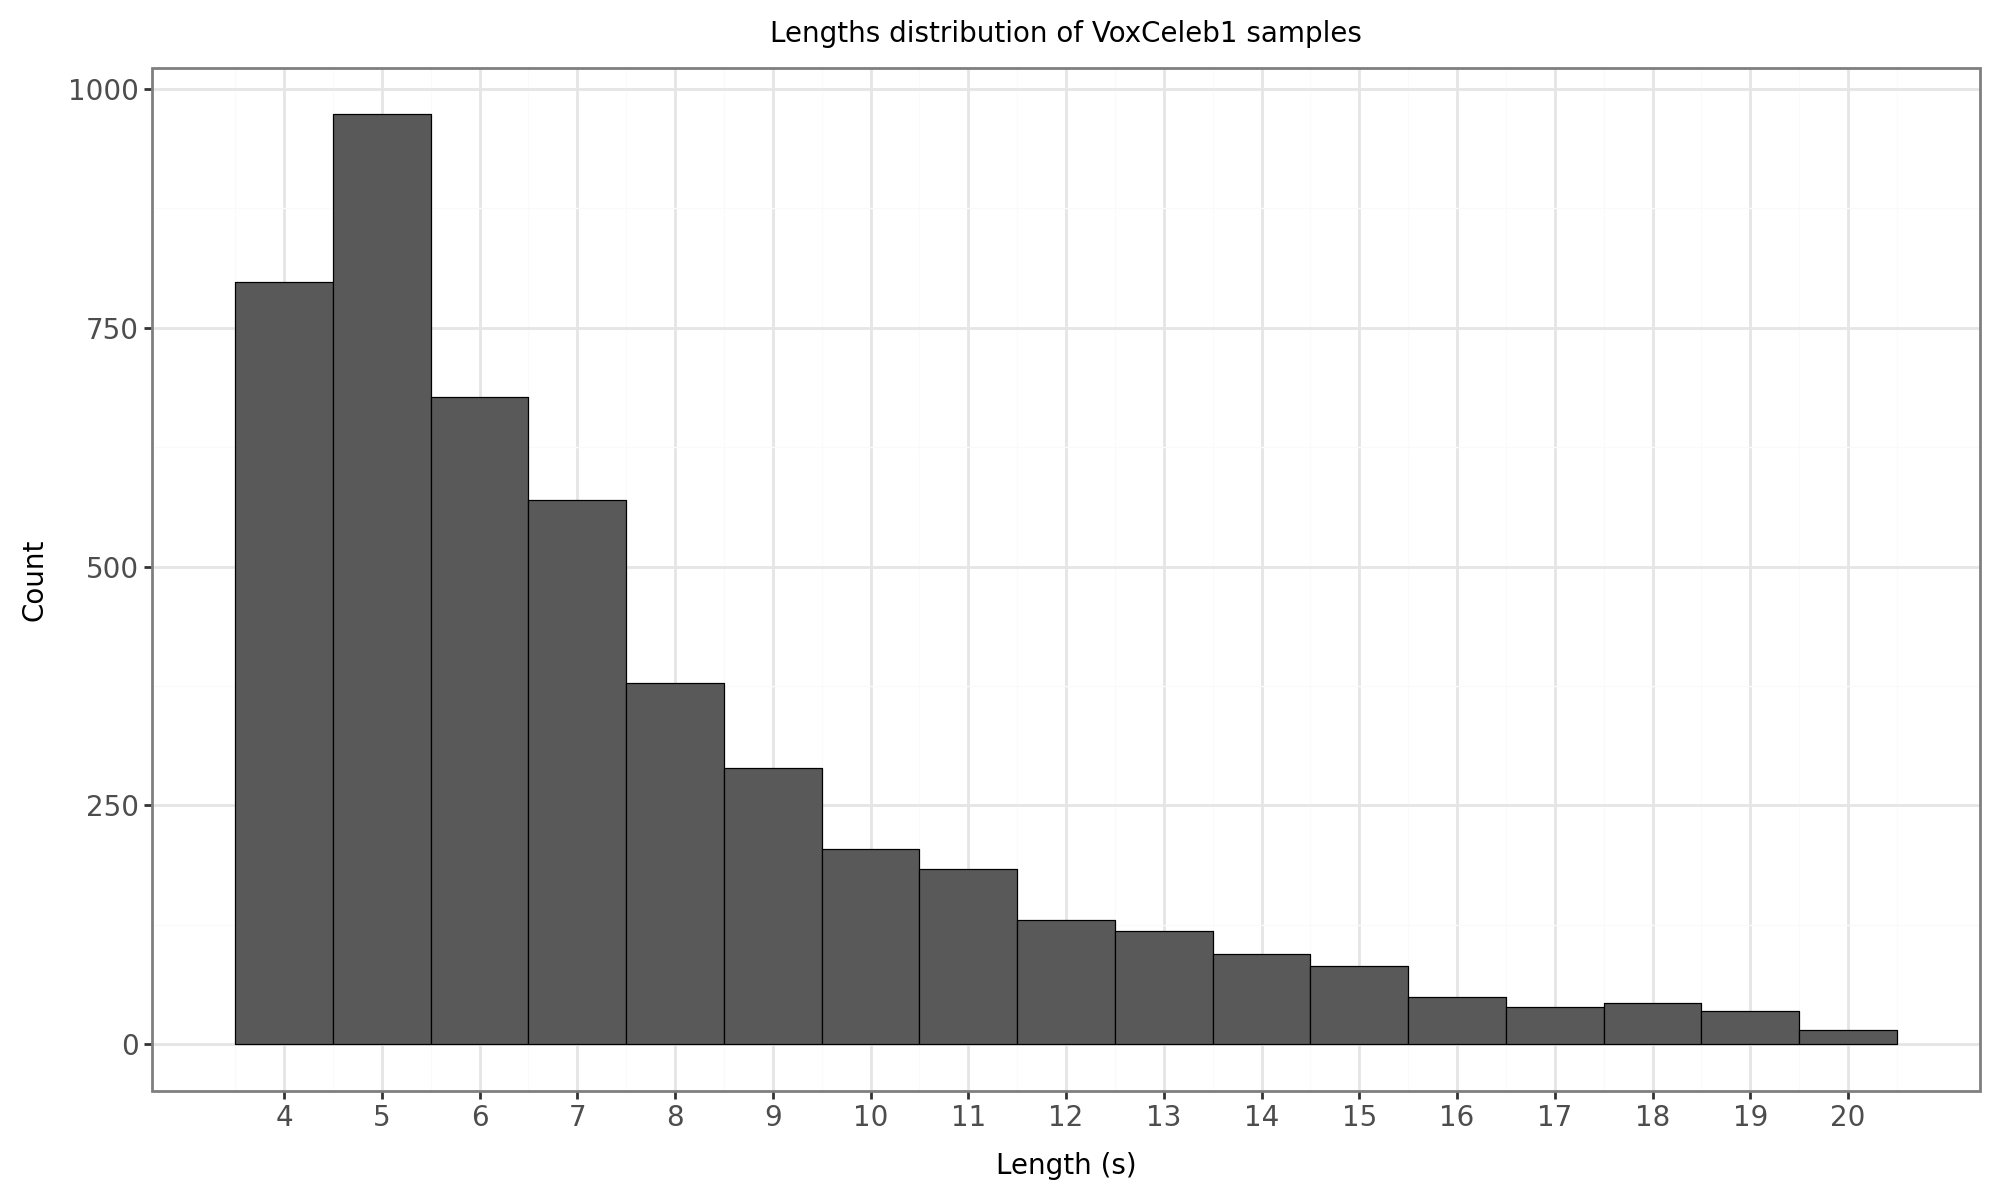

In [5]:
lengths = []

for file in tqdm(files):
    audio, sr = sf.read(file, dtype='int16')
    lengths.append(len(audio))

df_length = pd.DataFrame({'Length': lengths})
df_length['Length'] = df_length['Length'] / 16000
df_length = df_length.drop(df_length[df_length['Length'] > 20].index)

plot = (
    ggplot()
    + xlab('Length (s)')
    + ylab('Count')
    + ggtitle(f'Lengths distribution of {DATASET_NAME} samples')
    + theme_bw()
    + theme(figure_size=(10, 6), text=element_text(size=10))
    + geom_histogram(
        df_length,
        aes(x='Length'),
        binwidth=1,
        color='black',
        position='identity',
        size=0.25
    )
    + scale_x_continuous(breaks=list(range(4, 21, 1)))
)

plot

In [6]:
100 * len(df_length[df_length['Length'] <= 4]) / len(df_length)

1.6032492518170158

In [7]:
100 * len(df_length[df_length['Length'] > 10]) / len(df_length)

19.067977768277043

## Voice Activity Detection

100%|██████████| 4874/4874 [00:19<00:00, 254.95it/s]


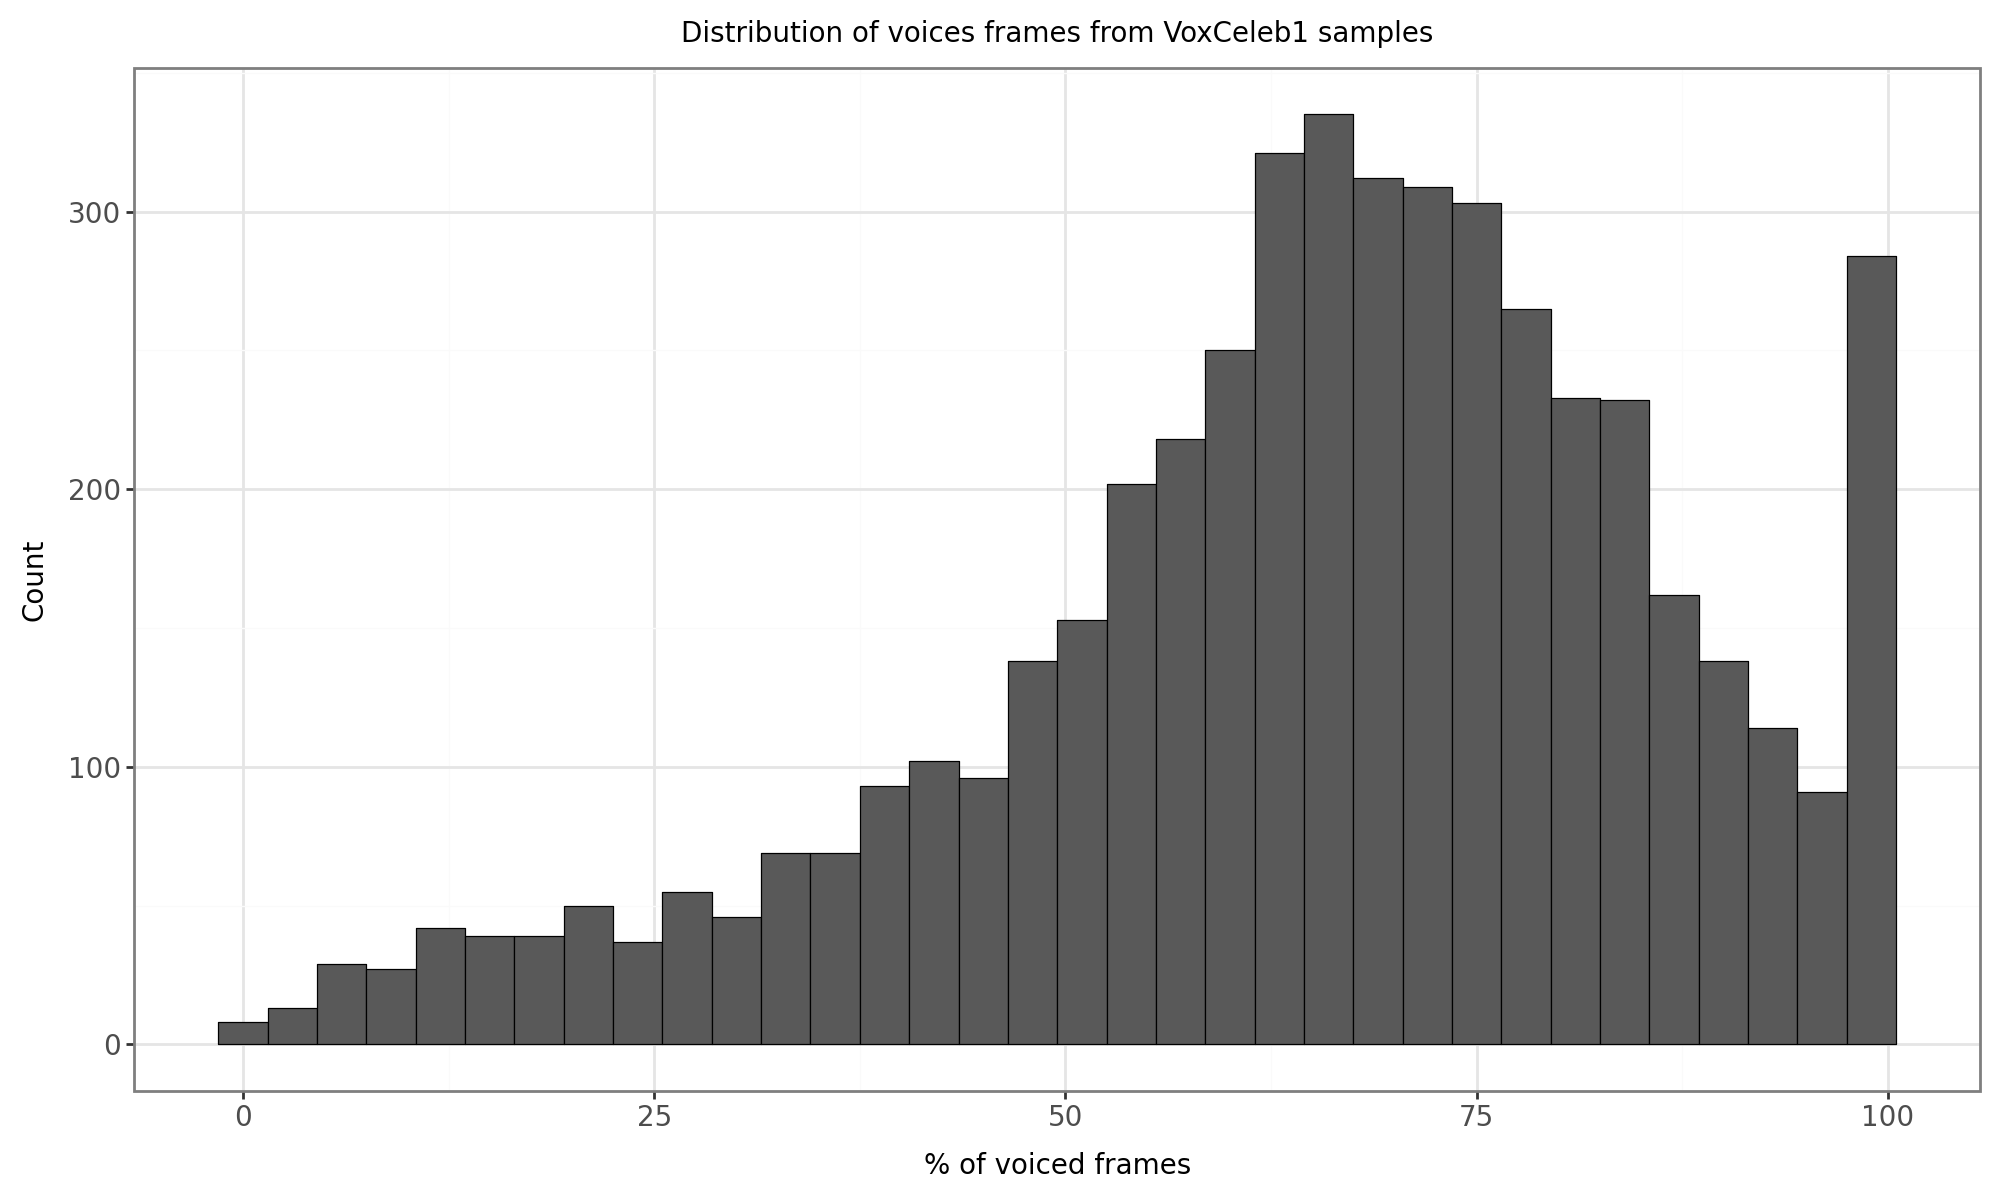

In [8]:
# sys.path.insert(0, 'notebooks/datasets')
# from VAD import VAD

from notebooks.datasets.VAD import VAD

vad = VAD(threshold=-20)

vads = []
for file in tqdm(files):
    audio, sr = sf.read(file, dtype='int16')
    _ = vad.apply(audio)
    vads.append(vad.last_vad.mean())

df_vad = pd.DataFrame({'VAD': vads})
df_vad['VAD'] = df_vad['VAD'] * 100

plot = (
    ggplot()
    + xlab('% of voiced frames')
    + ylab('Count')
    + ggtitle(f'Distribution of voices frames from {DATASET_NAME} samples')
    + theme_bw()
    + theme(figure_size=(10, 6), text=element_text(size=10))
    + geom_histogram(
        df_vad,
        aes(x='VAD'),
        binwidth=3,
        color='black',
        position='identity',
        size=0.25
    )
)

plot

In [9]:
100 * len(df_vad[df_vad['VAD'] >= 75]) / len(df_vad)

34.24292162494871

In [10]:
100 * len(df_vad[df_vad['VAD'] >= 50]) / len(df_vad)

80.11899876897826

In [11]:
100 * len(df_vad[df_vad['VAD'] <= 25]) / len(df_vad)

5.765285186704965